# Un cable que mejora al encogerse

Cada cable de cobre dentro de tu celular tiene un defecto de nacimiento: entre más delgado lo haces, **peor** conduce. Los electrones empiezan a rebotar contra las paredes del cable y la resistencia se dispara. Es el cuello de botella que hoy frena a los chips.

Un equipo probó lo contrario. Un nanohilo de arseniuro de niobio —NbAs— de 40 nanómetros, más fino que muchos virus, baja su resistividad a **10,5 µΩ·cm**: unos **70 % menos** que el mismo material en bloque. Encoger el cable lo mejoró.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Surface-dominant transport in Weyl semimetal NbAs nanowires for next-generation interconnects* — Cheon et al., Science, 393(6808), 2026.
**DOI:** [10.1126/science.adx3027](https://doi.org/10.1126/science.adx3027)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-16-nbas-nanowires-interconnects/notebook.ipynb)

## De dónde viene el problema

Dentro de un chip, los transistores hacen el cálculo, pero son los **interconectores** —diminutos cables de cobre— los que mueven la señal de un lado a otro. Al miniaturizar el chip, esos cables se adelgazan, y ahí el cobre falla: por debajo de ~100 nm su resistividad sube rápido porque los electrones chocan contra las superficies del cable.

El NbAs pertenece a una familia rara llamada **semimetales de Weyl**: materiales donde parte de la corriente viaja por estados que viven en la *superficie* del cristal, no en su interior. La idea del paper es que, al encoger el hilo, esa superficie pesa más frente al volumen, y por eso conducir mejora en lugar de empeorar.

Ojo con la certeza: que la conducción sea *dominada por la superficie* es una explicación que **los cálculos teóricos (DFT) atribuyen** al hilo — no algo medido directo. El dato duro y medido es la resistividad; el mecanismo es la hipótesis que lo explica.

Aquí no tenemos la curva resistividad-vs-diámetro (vive en una figura del paper que está tras muro de pago). Pero sí tenemos las **tablas del material suplementario**: cómo bota el calor, cuánta corriente aguanta y de qué está hecho. Vamos a esos datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
RESISTIVIDAD_40NM = 10.5      # µΩ·cm — resistividad del nanohilo de 40 nm (medida)
RESISTIVIDAD_INCERT = 1.9     # ± µΩ·cm
REDUCCION_VS_BULK = 70        # % menos que el material en bloque
DIAMETRO_MIN = 40             # nm — diámetro más fino sintetizado
K_NBAS = 109.68              # W/m·K — conductividad térmica, monocristal
K_CU = 401                   # W/m·K — cobre, la referencia
FUENTE = 'Fuente: Cheon et al. (2026), Science | Datos: Supplementary Tables S4-S8'

COLOR_DATOS = '#2563EB'       # NbAs, nuestra estrella
COLOR_ALERTA = '#DC2626'      # contraste / cobre en breakdown
COLOR_METAL = '#059669'       # metales de referencia (Ru, Co)
COLOR_REFERENCIA = '#D97706'  # umbral / cobre

# Fórmulas con subíndices Unicode para las etiquetas de gráficas
FORMULA = {'WTe2': 'WTe₂', 'Cd3As2': 'Cd₃As₂', 'TaSe3': 'TaSe₃'}
def formula(m):
    return FORMULA.get(m, m)

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Estilo CaM (local → /tmp inyectado → GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de las 4 tablas del material suplementario
termica = pd.read_csv('datos/conductividad_termica_materiales.csv')
ruptura = pd.read_csv('datos/densidad_corriente_ruptura.csv')
edx = pd.read_csv('datos/composicion_edx.csv')
lowk = pd.read_csv('datos/dielectricos_low_k.csv')

nbas_bd = ruptura[ruptura['este_trabajo'] == 1]['densidad_ruptura_ma_cm2']
print(f'Resistividad NbAs 40 nm : {RESISTIVIDAD_40NM} ± {RESISTIVIDAD_INCERT} microhm-cm  ({REDUCCION_VS_BULK}% menos que el bloque)')
print(f'Conductividad termica   : {K_NBAS} W/m-K  (cobre = {K_CU})')
print(f'Breakdown NbAs 40 nm    : n={len(nbas_bd)}, mediana={nbas_bd.median():.1f}, rango {nbas_bd.min()}-{nbas_bd.max()} MA/cm2')
print(f'Nanohilos analizados EDX: {(edx["muestra"] != "Bulk").sum()}')

Resistividad NbAs 40 nm : 10.5 ± 1.9 microhm-cm  (70% menos que el bloque)
Conductividad termica   : 109.68 W/m-K  (cobre = 401)
Breakdown NbAs 40 nm    : n=6, mediana=42.2, rango 25.8-78.7 MA/cm2
Nanohilos analizados EDX: 4


## Primero, algo que no debería pasar

Un buen interconector no solo lleva corriente: tiene que **sacar el calor** que genera, o el chip se cocina. Los metales lo hacen bien (el cobre es campeón). Los materiales cuánticos exóticos, casi nunca — suelen ser pésimos conductores de calor.

¿En cuál grupo cae el NbAs?

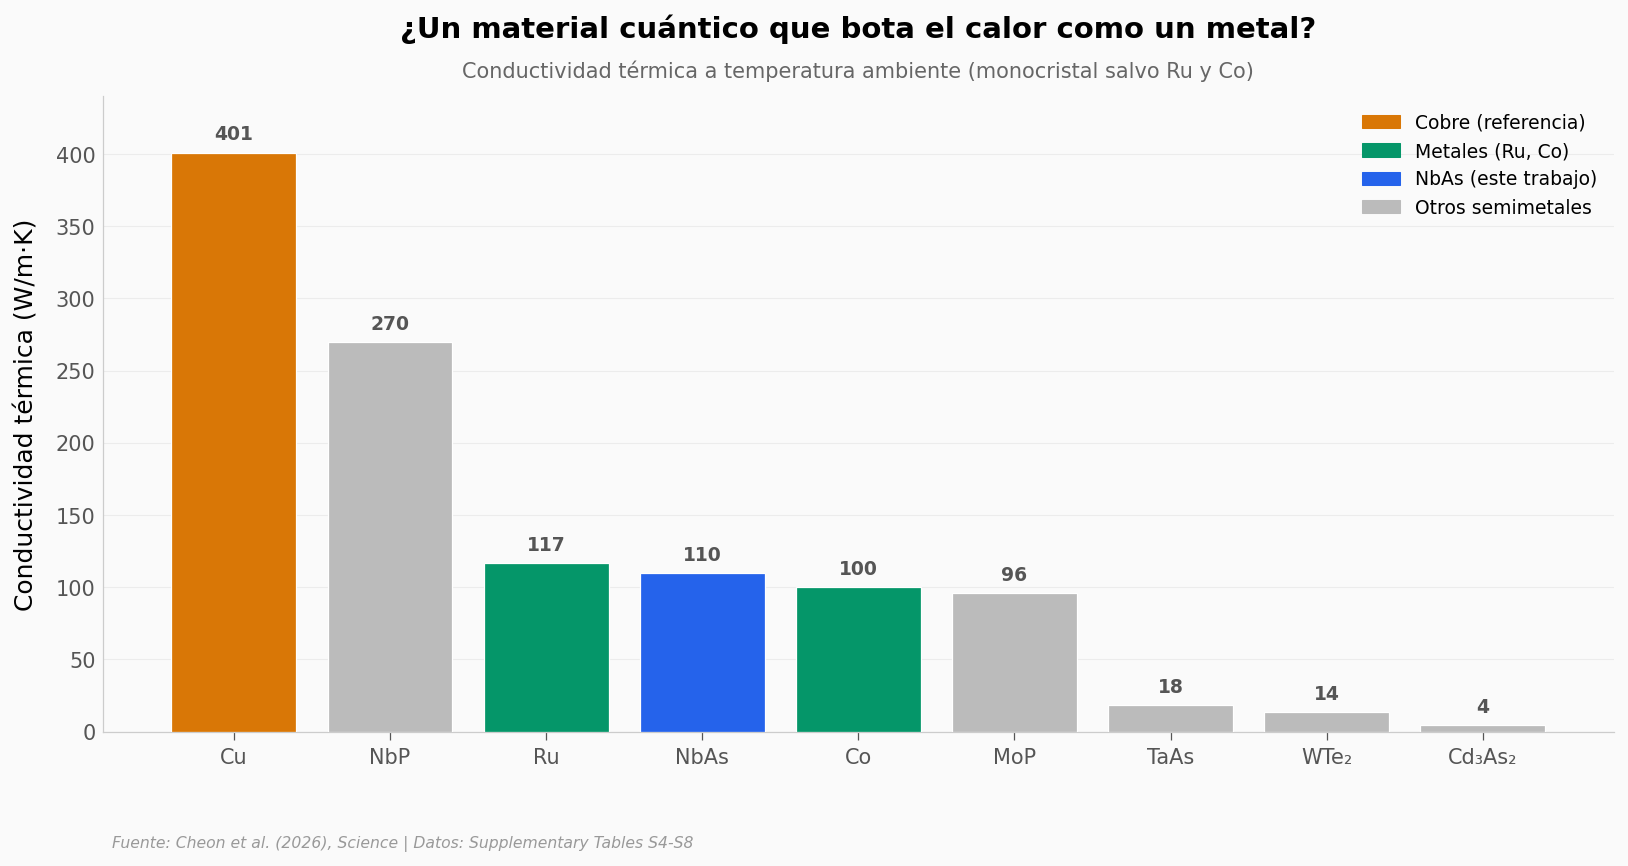

In [2]:
# Conductividad térmica: metales vs semimetales topológicos (monocristal)
sc = termica[termica['cristalinidad'] == 'Single crystal'].copy()
# Añadir cobre y dos metales policristalinos de referencia interconnect
metales = termica[termica['material'].isin(['Cu', 'Ru', 'Co'])][['material', 'conductividad_termica_wmk']]
comp = pd.concat([sc[['material', 'conductividad_termica_wmk']], metales], ignore_index=True)
comp = comp.drop_duplicates('material').sort_values('conductividad_termica_wmk', ascending=False).reset_index(drop=True)

def color_de(m):
    if m == 'Cu':
        return COLOR_REFERENCIA
    if m in ('Ru', 'Co'):
        return COLOR_METAL
    if m == 'NbAs':
        return COLOR_DATOS
    return '#BBBBBB'

colores = [color_de(m) for m in comp['material']]

fig, ax = plt.subplots(figsize=(13, 5.5))
xpos = np.arange(len(comp))
barras = ax.bar(xpos, comp['conductividad_termica_wmk'], color=colores,
                edgecolor='white', linewidth=0.6, zorder=3)
ax.set_xticks(xpos)
ax.set_xticklabels([formula(m) for m in comp['material']])
for b, v in zip(barras, comp['conductividad_termica_wmk']):
    ax.text(b.get_x() + b.get_width()/2, v + 6, f'{v:.0f}', ha='center', va='bottom',
            fontsize=9, color='#555555', fontweight='bold')

ax.set_title('¿Un material cuántico que bota el calor como un metal?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Conductividad térmica a temperatura ambiente (monocristal salvo Ru y Co)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Conductividad térmica (W/m·K)')
ax.set_ylim(0, 440)

handles = [Patch(color=COLOR_REFERENCIA, label='Cobre (referencia)'),
           Patch(color=COLOR_METAL, label='Metales (Ru, Co)'),
           Patch(color=COLOR_DATOS, label='NbAs (este trabajo)'),
           Patch(color='#BBBBBB', label='Otros semimetales')]
ax.legend(handles=handles, loc='upper right', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/conductividad_termica.png', dpi=200, bbox_inches='tight')
plt.show()

El NbAs se sienta entre el rutenio y el cobalto, dos metales que la industria ya estudia como reemplazo del cobre. Está en la liga de los metales para mover calor — muy lejos del pelotón de semimetales de la derecha (TaAs, WTe₂, Cd₃As₂), que apenas conducen.

Dos honestidades: el cobre sigue arriba de todos (401 contra 110, casi cuatro veces), y entre los semimetales el NbAs **no es el mejor** — el NbP lo supera. Lo notable no es que gane, sino que un material con física de Weyl mueva calor como un metal común, algo que casi ningún primo suyo logra.

## ¿Y de verdad es NbAs a esa escala?

Fabricar un cristal perfecto de 40 nm es difícil: es fácil terminar con más niobio que arsénico, o al revés, y eso arruinaría las propiedades. Antes de creerle a cualquier medición, toca preguntar si el hilo tiene la composición correcta.

El equipo midió la proporción de átomos (Nb frente a As) en cuatro nanohilos con espectroscopía de rayos X (EDX). Un NbAs perfecto es 1 a 1.

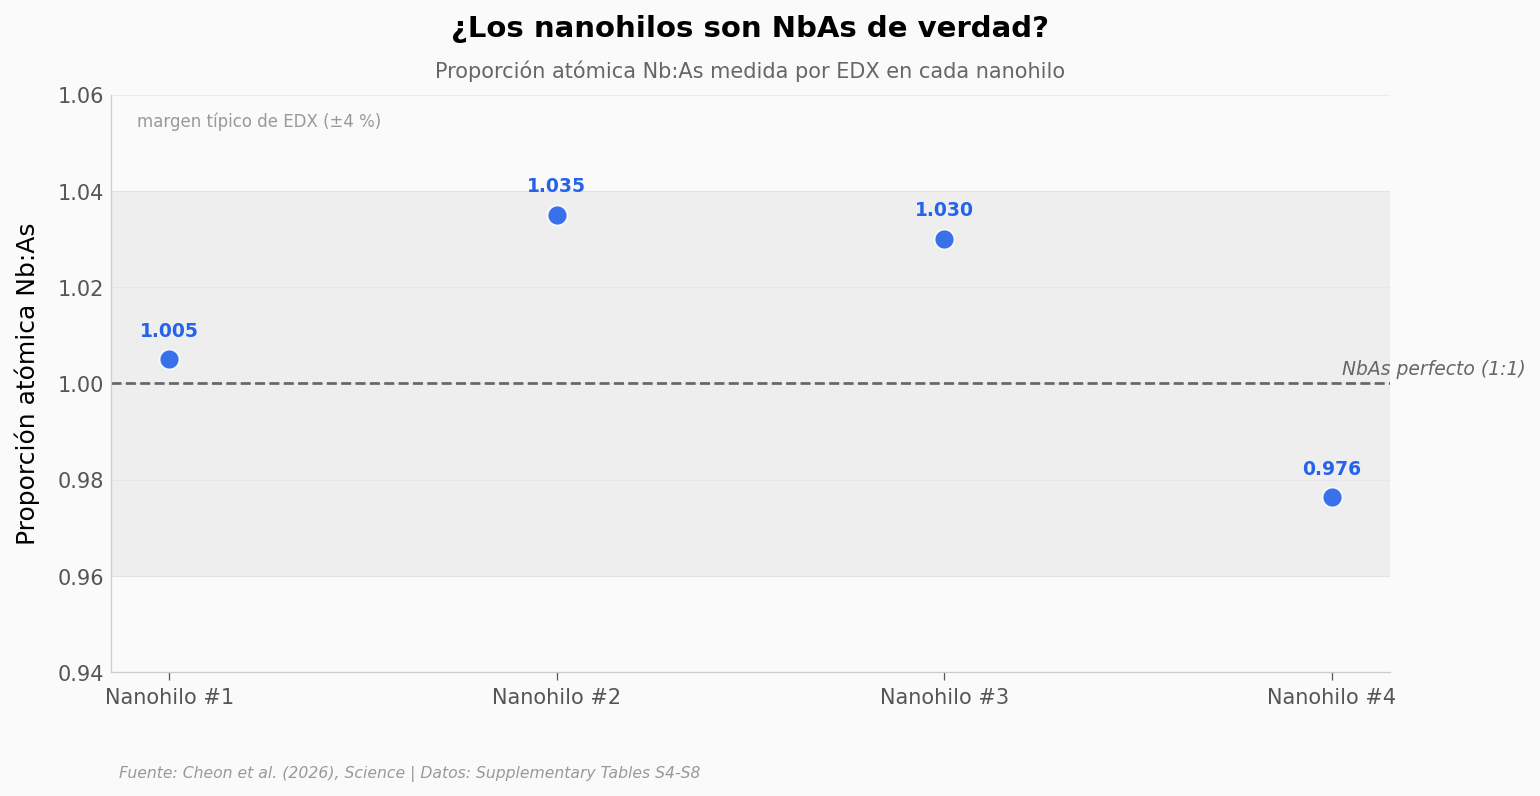

Proporción media Nb:As en nanohilos: 1.012
Desviación máxima respecto a 50/50: 0.9 puntos porcentuales


In [3]:
# Proporción atómica Nb:As en cada nanohilo (1.0 = estequiometría perfecta)
nw = edx[edx['muestra'] != 'Bulk'].reset_index(drop=True)
bulk_ratio = edx[edx['muestra'] == 'Bulk']['nb_as_atomic_ratio'].iloc[0]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(nw))
ax.axhline(1.0, color='#666666', linewidth=1.3, linestyle='--', zorder=2)
ax.text(len(nw) - 0.5, 1.001, 'NbAs perfecto (1:1)', ha='right', va='bottom',
        fontsize=9, color='#666666', style='italic')
# banda de incertidumbre típica de EDX (±4% en la proporción)
ax.axhspan(0.96, 1.04, color='#BBBBBB', alpha=0.18, zorder=1)
ax.text(0.02, 0.97, 'margen típico de EDX (±4 %)', transform=ax.transAxes,
        fontsize=8, color='#999999', va='top')

ax.scatter(x, nw['nb_as_atomic_ratio'], color=COLOR_DATOS, s=90, alpha=0.9,
           edgecolors='white', linewidths=0.8, zorder=5)
for xi, yi in zip(x, nw['nb_as_atomic_ratio']):
    ax.text(xi, yi + 0.004, f'{yi:.3f}', ha='center', va='bottom', fontsize=9,
            color=COLOR_DATOS, fontweight='bold')

ax.set_title('¿Los nanohilos son NbAs de verdad?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Proporción atómica Nb:As medida por EDX en cada nanohilo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks(x)
ax.set_xticklabels([n.replace('Nanowire', 'Nanohilo') for n in nw['muestra']], fontsize=10)
ax.set_ylabel('Proporción atómica Nb:As')
ax.set_ylim(0.94, 1.06)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/composicion_edx.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Proporción media Nb:As en nanohilos: {nw["nb_as_atomic_ratio"].mean():.3f}')
print(f'Desviación máxima respecto a 50/50: {(nw[["nb_at_pct","as_at_pct"]] - 50).abs().max().max():.1f} puntos porcentuales')

Los cuatro nanohilos caen dentro del margen de error de la técnica: la desviación mayor es de menos de un punto porcentual respecto al 50/50. El proceso de fabricación no rompió la receta — sigue siendo NbAs, átomo por átomo.

Composición correcta y buen manejo del calor. Falta la prueba dura de un cable: **¿cuánta corriente aguanta antes de fundirse?**

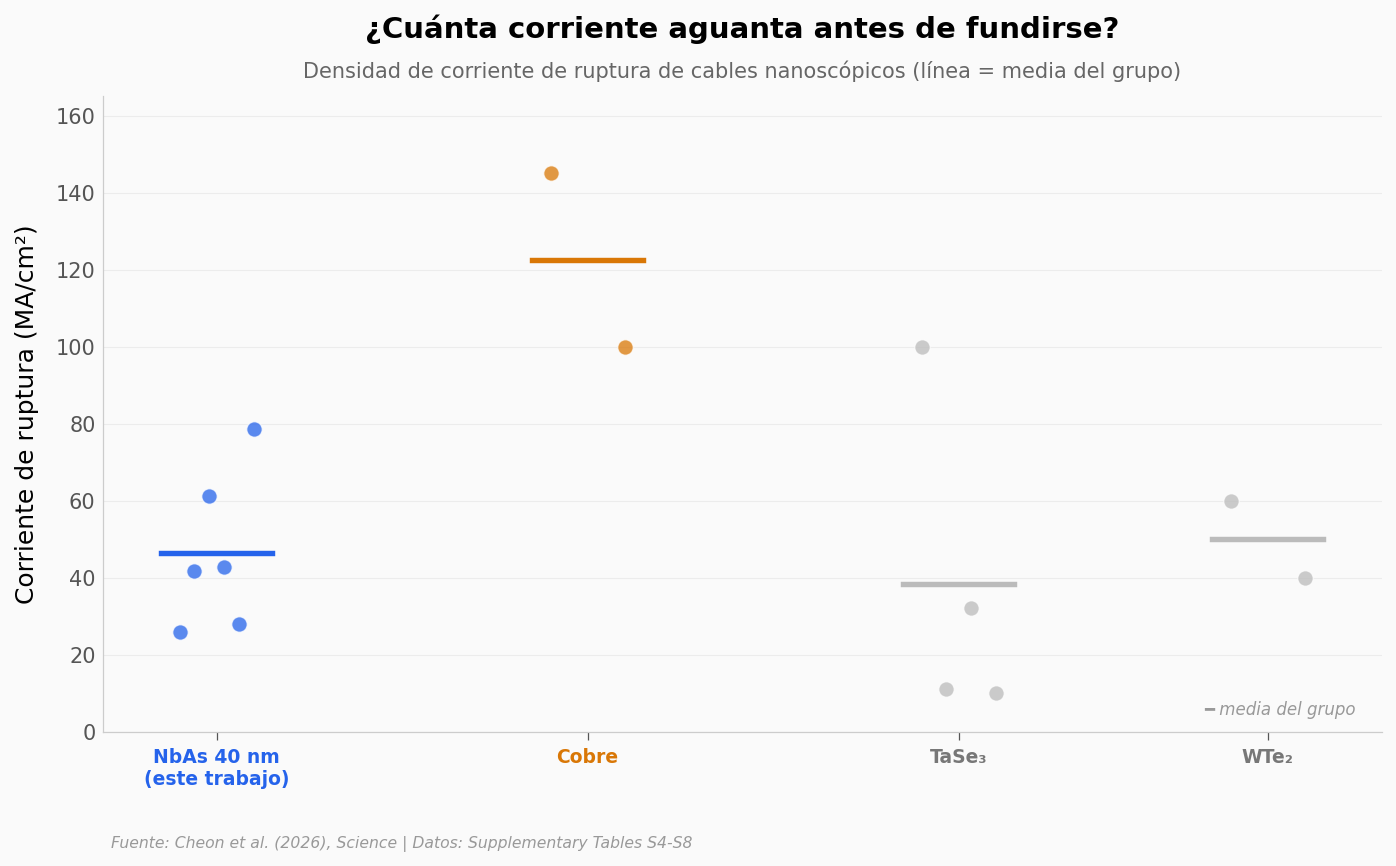

NbAs 40 nm: n=6, media=46.3, mediana=42.2, rango 25.8-78.7 MA/cm2
Cobre: [100.0, 145.0] MA/cm2


In [4]:
# Densidad de corriente de ruptura: NbAs @40nm vs otras alternativas nanoscópicas
np.random.seed(42)
grupos = [
    ('NbAs 40 nm\n(este trabajo)', ruptura[ruptura['este_trabajo'] == 1]['densidad_ruptura_ma_cm2'].values, COLOR_DATOS),
    ('Cobre',   ruptura[ruptura['material'] == 'Cu nanowire']['densidad_ruptura_ma_cm2'].values, COLOR_REFERENCIA),
    ('TaSe₃',   ruptura[ruptura['material'] == 'TaSe3 nanowire']['densidad_ruptura_ma_cm2'].values, '#BBBBBB'),
    ('WTe₂',    ruptura[ruptura['material'].str.startswith('WTe2')]['densidad_ruptura_ma_cm2'].values, '#BBBBBB'),
]
posiciones = [0, 1.2, 2.4, 3.4]

fig, ax = plt.subplots(figsize=(11, 5.5))
for pos, (nombre, vals, color) in zip(posiciones, grupos):
    n = len(vals)
    xj = np.linspace(pos - 0.12, pos + 0.12, n)
    np.random.shuffle(xj)
    ax.scatter(xj, vals, color=color, s=55, alpha=0.75, edgecolors='white',
               linewidths=0.6, zorder=5)
    ax.plot([pos - 0.18, pos + 0.18], [vals.mean(), vals.mean()], color=color,
            linewidth=2.6, zorder=6)

ax.set_title('¿Cuánta corriente aguanta antes de fundirse?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Densidad de corriente de ruptura de cables nanoscópicos (línea = media del grupo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks(posiciones)
ax.set_xticklabels([g[0] for g in grupos], fontsize=9, fontweight='bold')
for tick, g in zip(ax.get_xticklabels(), grupos):
    tick.set_color(g[2] if g[2] != '#BBBBBB' else '#777777')
ax.set_ylabel('Corriente de ruptura (MA/cm²)')
ax.set_ylim(0, 165)
ax.text(0.98, 0.02, '━ media del grupo', transform=ax.transAxes, fontsize=8,
        color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/corriente_ruptura.png', dpi=200, bbox_inches='tight')
plt.show()

nb = grupos[0][1]
print(f'NbAs 40 nm: n={len(nb)}, media={nb.mean():.1f}, mediana={np.median(nb):.1f}, rango {nb.min()}-{nb.max()} MA/cm2')
print(f'Cobre: {sorted(grupos[1][1].tolist())} MA/cm2')

Aquí toca ser justos: **el cobre aguanta más corriente** (100 y 145 contra una mediana de 42 en el NbAs). Si la pregunta fuera solo "cuánta corriente resiste", el cobre gana.

Pero el NbAs deja atrás a los otros candidatos exóticos —TaSe₃ y WTe₂— y llega a picos de casi 79 MA/cm². O sea: aguanta corrientes enormes sin que ese sea siquiera su punto fuerte. Su ventaja real está en la resistividad y en el manejo del calor, no en el breakdown.

Pongamos ese número en el mapa de todos los cables nanoscópicos reportados.

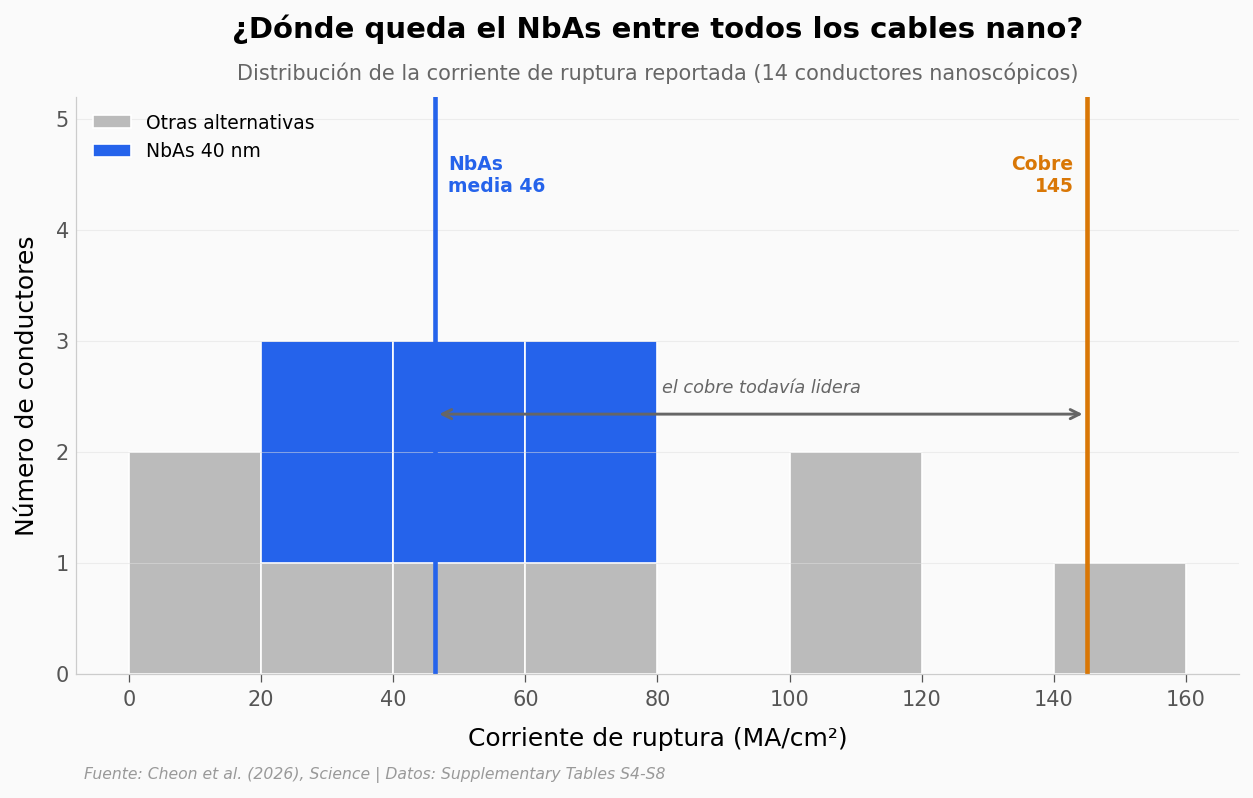

In [5]:
# Dónde cae el NbAs en el paisaje de corriente de ruptura reportada
todos = ruptura['densidad_ruptura_ma_cm2'].values
es_nbas = ruptura['este_trabajo'].values == 1
media_nbas = todos[es_nbas].mean()
cu_max = ruptura[ruptura['material'] == 'Cu nanowire']['densidad_ruptura_ma_cm2'].max()

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 160, 9)
ax.hist([todos[~es_nbas], todos[es_nbas]], bins=bins, stacked=True,
        color=['#BBBBBB', COLOR_DATOS], edgecolor='white', linewidth=0.8,
        label=['Otras alternativas', 'NbAs 40 nm'])
y_max = 5.2
ax.set_ylim(0, y_max)

ax.axvline(media_nbas, color=COLOR_DATOS, linewidth=2.2)
ax.text(media_nbas + 2, y_max * 0.9, f'NbAs\nmedia {media_nbas:.0f}', color=COLOR_DATOS,
        fontsize=9, fontweight='bold', va='top')
ax.axvline(cu_max, color=COLOR_REFERENCIA, linewidth=2.2)
ax.text(cu_max - 2, y_max * 0.9, f'Cobre\n{cu_max:.0f}', color=COLOR_REFERENCIA,
        fontsize=9, fontweight='bold', va='top', ha='right')
ax.annotate('', xy=(cu_max, y_max * 0.45), xytext=(media_nbas, y_max * 0.45),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.4))
ax.text((media_nbas + cu_max)/2, y_max * 0.48, 'el cobre todavía lidera',
        ha='center', va='bottom', fontsize=8.5, color='#666666', style='italic')

ax.set_title('¿Dónde queda el NbAs entre todos los cables nano?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de la corriente de ruptura reportada (14 conductores nanoscópicos)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Corriente de ruptura (MA/cm²)')
ax.set_ylabel('Número de conductores')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_ruptura.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El nanohilo de 40 nm baja su resistividad ~70 % frente al bloque | ✅ | Dato medido del abstract (10,5 ± 1,9 µΩ·cm). La curva completa vive en el paper paywalled; aquí se cita, no se re-mide. |
| La conducción es "dominada por la superficie" | ⚠️ | Mecanismo **atribuido por cálculos DFT**, no medido directo. Explica la resistividad, pero es la hipótesis, no el dato. |
| El NbAs bota el calor como un metal | ✅ | 109,68 W/m·K (monocristal), en la liga de Ru (117) y Co (100). Pero es el 27 % del cobre (401) y el NbP lo supera. |
| Los nanohilos son NbAs estequiométrico | ✅ | Proporción atómica Nb:As media 1,012; desviación máxima <1 punto porcentual, dentro del margen de EDX. |
| El NbAs aguanta más corriente que el cobre | ❌ | Falso: el cobre (100–145) supera al NbAs (mediana 42 MA/cm²). El NbAs sí bate a TaSe₃ y WTe₂. |

> **Limitaciones:** la resistividad-vs-diámetro (el hallazgo central) no está en estos CSV — se cita del abstract. Las comparaciones de breakdown y térmica usan pocos puntos por material (n=2–6), suficientes para ubicar órdenes de magnitud, no para tests estadísticos finos. El mecanismo de superficie es teórico (DFT), no una medición directa.

## Ahora tú

1. **¿Y si el cobre no fuera la vara?** En la celda del histograma, cambia `cu_max` por el valor de otro material (TaSe₃ llega a 32) y mira cómo se mueve la flecha. ¿Contra quién sí gana claramente el NbAs?

2. **La liga térmica.** En la gráfica hero, ¿qué pasa si separas metales y semimetales en dos grupos y sacas la media de cada uno? Prueba `comp.groupby(...)` — ¿de qué lado cae el NbAs?

3. **El margen de EDX.** La banda gris asume ±3 %. Si la estrechas a ±1 % (`axhspan(0.99, 1.01, ...)`), ¿algún nanohilo se sale? ¿Qué tan exigente es "estequiométrico"?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuántas veces mejor conductor de calor es el NbAs que el promedio
# de los otros semimetales topológicos (excluyendo NbP y MoP)?
sc = termica[termica['cristalinidad'] == 'Single crystal']
otros = sc[~sc['material'].isin(['NbP', 'NbAs', 'MoP'])]['conductividad_termica_wmk']

print(f'NbAs (monocristal)      : {K_NBAS:.1f} W/m·K')
print(f'Otros semimetales (media): {otros.mean():.1f} W/m·K  ->  {", ".join(sc[~sc["material"].isin(["NbP","NbAs","MoP"])]["material"])}')
print(f'El NbAs conduce {K_NBAS / otros.mean():.1f}x mejor el calor que ese grupo.')
print(f'Frente al cobre, en cambio, es apenas el {K_NBAS / K_CU * 100:.0f}%.')

NbAs (monocristal)      : 109.7 W/m·K
Otros semimetales (media): 12.1 W/m·K  ->  TaAs, WTe2, Cd3As2
El NbAs conduce 9.1x mejor el calor que ese grupo.
Frente al cobre, en cambio, es apenas el 27%.


---

## Fuentes

**Paper**: [Surface-dominant transport in Weyl semimetal NbAs nanowires for next-generation interconnects](https://doi.org/10.1126/science.adx3027)  
*Science, 2026-07-16 · paywall*

**Supplementary Material**: [Tablas S4, S5, S7, S8](https://www.science.org/doi/suppl/10.1126/science.adx3027/suppl_file/science.adx3027_sm.pdf)  
*Science, 2026-07-16 · datos abiertos*

*13 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook del Lab de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos reproducibles en [GitHub](https://github.com/Ciencia-a-Mordiscos/lab). Licencia de los datos: material suplementario de Science, uso educativo con atribución.*